# Test các cấu hình Deterministic trên TPU v6e-1

**TPU Target**: Google Cloud TPU v6e-1  
**Architecture**: v6e (Edge TPU)  
**TF32 Support**: ❌ Không hỗ trợ (TF32 là tính năng NVIDIA GPU)  
**Precision**: BFloat16 (mặc định cho TPU), FP32

**Mục tiêu**: Test các phương pháp khắc phục vấn đề reproducibility trên TPU v6e-1:
1. TF32 (TPU không hỗ trợ, nên không có test này)
2. Tắt AMP (Automatic Mixed Precision)
3. Tắt cuDNN benchmark (không áp dụng cho TPU)
4. Đặt num_workers = 0
5. Bật deterministic algorithms (nếu hỗ trợ)

**Kỳ vọng**: Với các cấu hình này, kết quả sẽ gần giống nhau hơn (nhưng vẫn có thể khác do floating-point precision và XLA compilation).


## 1. Cài đặt torch_xla và kiểm tra TPU


In [1]:
# Cài đặt torch_xla (chạy lần đầu tiên)
# !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools
# Import torch_xla cho TPU
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    # Import runtime module cho world_size (torch_xla 2.7+)
    try:
        import torch_xla.runtime as xr
        RUNTIME_AVAILABLE = True
    except ImportError:
        RUNTIME_AVAILABLE = False
    TPU_AVAILABLE = True
    print(f"torch_xla version: {torch_xla.__version__}")
except ImportError:
    TPU_AVAILABLE = False
    RUNTIME_AVAILABLE = False
    print("⚠️  torch_xla chưa được cài đặt!")
    print("   Chạy: !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html")

# Kiểm tra TPU
print(f"\nPyTorch version: {torch.__version__}")
if TPU_AVAILABLE:
    # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
    try:
        device = torch_xla.device()
    except:
        device = xm.xla_device()  # Fallback cho phiên bản cũ
    print(f"TPU Device: {device}")

    # Lấy device hardware info
    try:
        device_hw = xm.xla_device_hw(device)
        print(f"TPU Device Type: {device_hw}")
    except:
        device_hw = "Unknown"
        print(f"TPU Device Type: {device_hw}")

    # Kiểm tra số TPU cores - sử dụng API mới
    try:
        if RUNTIME_AVAILABLE:
            num_cores = xr.world_size()
        else:
            # Fallback: thử API cũ hoặc đặt mặc định
            try:
                num_cores = xm.xrt_world_size()
            except:
                num_cores = 1  # Mặc định nếu không lấy được
        print(f"Số TPU cores: {num_cores}")
    except Exception as e:
        print(f"Không thể lấy số TPU cores: {e}")
        num_cores = 1

    # Xác nhận TPU v6e-1
    if "v6e" in device_hw.lower() or "v6" in device_hw.lower():
        print(f"\n✓ Đã xác nhận: TPU v6e")
    else:
        print(f"\n⚠️  CẢNH BÁO: TPU hiện tại ({device_hw}) có thể không phải v6e-1!")
        print("   Notebook này được thiết kế cho TPU v6e-1.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
else:
    print("❌ Không tìm thấy TPU hoặc torch_xla chưa được cài đặt!")
    print("   Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU VM hoặc Colab với TPU.")


torch_xla version: 2.9.0

PyTorch version: 2.9.0+cpu
TPU Device: xla:0
TPU Device Type: TPU
Số TPU cores: 1

⚠️  CẢNH BÁO: TPU hiện tại (TPU) có thể không phải v6e-1!
   Notebook này được thiết kế cho TPU v6e-1.
   Vẫn tiếp tục nhưng kết quả có thể khác.


## 2. Định nghĩa các hàm helper


In [2]:
def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phai la top-level function de pickle duoc)"""
    np.random.seed(seed_val + worker_id)

def set_seed(seed=42, deterministic=False):
    """Thiết lập seed với tùy chọn deterministic mode"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    # TPU không có cuda, nên không cần torch.cuda.manual_seed

    if deterministic:
        # Lưu ý: use_deterministic_algorithms có thể làm chậm và không hỗ trợ tất cả operations
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms cho tất cả operations")

def setup_environment_deterministic(bf16_enabled=True, amp_enabled=False,
                                     num_workers=4, deterministic_algorithms=False):
    """
    Thiết lập môi trường với các tùy chọn deterministic cho TPU

    Args:
        bf16_enabled: Bật/tắt BFloat16 (TPU hỗ trợ tốt, mặc định bật)
        amp_enabled: Bật/tắt Automatic Mixed Precision (không cần thiết với TPU)
        num_workers: Số worker (0 = deterministic, mặc định 4 cho Linux/Unix)
        deterministic_algorithms: Bật deterministic algorithms (có thể chậm)
    """
    # TPU không có TF32 (đây là tính năng NVIDIA GPU)
    # TPU không có cuDNN benchmark (đây là tính năng NVIDIA GPU)

    if deterministic_algorithms:
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms")

    if TPU_AVAILABLE:
        try:
            # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
            try:
                device = torch_xla.device()
            except:
                device = xm.xla_device()  # Fallback cho phiên bản cũ
            tpu_name = xm.xla_device_hw(device)
        except:
            tpu_name = 'Unknown'

        # Lấy số cores - sử dụng API mới
        try:
            if RUNTIME_AVAILABLE:
                num_cores = xr.world_size()
            else:
                try:
                    num_cores = xm.xrt_world_size()
                except:
                    num_cores = 1
        except:
            num_cores = 1

        device_name = f"TPU {tpu_name}"
    else:
        tpu_name = 'N/A'
        num_cores = 0
        device_name = 'TPU N/A'

    config = {
        'tf32_enabled': False,  # TPU không hỗ trợ
        'bf16_enabled': bf16_enabled,  # TPU hỗ trợ bfloat16
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'cudnn_benchmark': False,  # TPU không có cuDNN
        'deterministic_algorithms': deterministic_algorithms,
        'gpu_name': device_name,  # Tương thích với notebook phân tích
        'tpu_name': tpu_name,
        'num_cores': num_cores
    }

    return config

class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 (tối ưu cho Linux/Unix)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader - su dung functools.partial voi function doc lap
    # (tranh loi pickle voi nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 3. Hàm training (cho TPU)


In [3]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """Train mô hình với cấu hình cụ thể trên TPU"""
    if not TPU_AVAILABLE:
        print("❌ TPU không khả dụng! Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU.")
        return None

    set_seed(seed, deterministic=config.get('deterministic_algorithms', False))

    # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
    try:
        device = torch_xla.device()
    except:
        device = xm.xla_device()  # Fallback cho phiên bản cũ

    trainloader, testloader = get_cifar10_loaders(
        batch_size=128,
        num_workers=config['num_workers'],
        seed=seed
    )

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }

    print(f"\n{'='*70}")
    print(f"TPU: {config['gpu_name']}")
    print(f"Config: TF32={config['tf32_enabled']} (TPU không hỗ trợ), BFloat16={config['bf16_enabled']}, "
          f"AMP={config['amp_enabled']}, Workers={config['num_workers']}, "
          f"Deterministic={config.get('deterministic_algorithms', False)}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # TPU sử dụng bfloat16 mặc định
            if config['bf16_enabled']:
                # Sử dụng torch.autocast với device_type='xla' cho TPU
                with torch.autocast(device_type='xla', dtype=torch.bfloat16):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()

            # Sử dụng xm.optimizer_step() cho TPU thay vì optimizer.step()
            xm.optimizer_step(optimizer)

            # Đồng bộ TPU sau mỗi step
            xm.mark_step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

                # Đồng bộ TPU
                xm.mark_step()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = config['gpu_name'].replace(' ', '_').replace('TPU ', '')
        config_str = f"bf16_{config['bf16_enabled']}_amp_{config['amp_enabled']}_w{config['num_workers']}_det{config.get('deterministic_algorithms', False)}"
        filename = f"results/deterministic_{gpu_name_short}_{config_str}_{timestamp}.json"

        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")

    return history


## 4. Test các cấu hình khác nhau trên TPU v6e-1

### 4.1 Cấu hình mặc định (BFloat16, 4 workers)


In [4]:
# Config 1: Mặc định (BFloat16 bật, 4 workers)
config_default = setup_environment_deterministic(
    bf16_enabled=True,  # TPU hỗ trợ tốt
    amp_enabled=False,
    num_workers=4,
    deterministic_algorithms=False
)
history_default = train_model(config_default, seed=42, num_epochs=10)


100%|██████████| 170M/170M [00:06<00:00, 26.3MB/s]



TPU: TPU TPU
Config: TF32=False (TPU không hỗ trợ), BFloat16=True, AMP=False, Workers=4, Deterministic=False



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-49568364.py:68: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-49568364.py:96: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4508, Train Acc: 46.49% | Test Loss: 1.1383, Test Acc: 58.69%
Epoch 2/10: Train Loss: 1.1394, Train Acc: 59.30% | Test Loss: 0.9153, Test Acc: 67.63%
Epoch 3/10: Train Loss: 1.0214, Train Acc: 63.55% | Test Loss: 0.8735, Test Acc: 69.16%
Epoch 4/10: Train Loss: 0.9399, Train Acc: 66.63% | Test Loss: 0.8367, Test Acc: 70.52%
Epoch 5/10: Train Loss: 0.8926, Train Acc: 68.41% | Test Loss: 0.7595, Test Acc: 73.30%
Epoch 6/10: Train Loss: 0.8539, Train Acc: 69.62% | Test Loss: 0.7481, Test Acc: 73.44%
Epoch 7/10: Train Loss: 0.8218, Train Acc: 70.76% | Test Loss: 0.6976, Test Acc: 75.68%
Epoch 8/10: Train Loss: 0.7926, Train Acc: 72.08% | Test Loss: 0.6724, Test Acc: 76.50%
Epoch 9/10: Train Loss: 0.7585, Train Acc: 73.27% | Test Loss: 0.6684, Test Acc: 76.89%
Epoch 10/10: Train Loss: 0.7469, Train Acc: 73.54% | Test Loss: 0.6555, Test Acc: 76.82%

✓ Kết quả đã lưu: results/deterministic_TPU_TPU_bf16_True_amp_False_w4_detFalse_20251226_085416.json


### 4.2 Tắt BFloat16 (FP32)


In [5]:
# Config 2: Tắt BFloat16 (FP32)
config_fp32 = setup_environment_deterministic(
    bf16_enabled=False,  # Sử dụng FP32
    amp_enabled=False,
    num_workers=4,
    deterministic_algorithms=False
)
history_fp32 = train_model(config_fp32, seed=42, num_epochs=10)



TPU: TPU TPU
Config: TF32=False (TPU không hỗ trợ), BFloat16=False, AMP=False, Workers=4, Deterministic=False



/tmp/ipython-input-49568364.py:68: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-49568364.py:96: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4551, Train Acc: 46.61% | Test Loss: 1.1729, Test Acc: 57.42%
Epoch 2/10: Train Loss: 1.1374, Train Acc: 58.92% | Test Loss: 0.9280, Test Acc: 67.00%
Epoch 3/10: Train Loss: 1.0210, Train Acc: 63.47% | Test Loss: 0.8459, Test Acc: 70.29%
Epoch 4/10: Train Loss: 0.9499, Train Acc: 66.20% | Test Loss: 0.8404, Test Acc: 70.35%
Epoch 5/10: Train Loss: 0.8915, Train Acc: 68.44% | Test Loss: 0.7648, Test Acc: 73.15%
Epoch 6/10: Train Loss: 0.8528, Train Acc: 69.68% | Test Loss: 0.7407, Test Acc: 73.91%
Epoch 7/10: Train Loss: 0.8216, Train Acc: 70.96% | Test Loss: 0.7495, Test Acc: 74.32%
Epoch 8/10: Train Loss: 0.7926, Train Acc: 71.91% | Test Loss: 0.6761, Test Acc: 75.79%
Epoch 9/10: Train Loss: 0.7657, Train Acc: 73.09% | Test Loss: 0.6508, Test Acc: 77.47%
Epoch 10/10: Train Loss: 0.7436, Train Acc: 73.78% | Test Loss: 0.6707, Test Acc: 76.64%

✓ Kết quả đã lưu: results/deterministic_TPU_TPU_bf16_False_amp_False_w4_detFalse_20251226_085530.json


### 4.3 num_workers = 0


In [6]:
# Config 3: num_workers = 0
config_no_workers = setup_environment_deterministic(
    bf16_enabled=True,
    amp_enabled=False,
    num_workers=0,
    deterministic_algorithms=False
)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)



TPU: TPU TPU
Config: TF32=False (TPU không hỗ trợ), BFloat16=True, AMP=False, Workers=0, Deterministic=False



/tmp/ipython-input-49568364.py:68: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-49568364.py:96: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4647, Train Acc: 46.08% | Test Loss: 1.1552, Test Acc: 57.92%
Epoch 2/10: Train Loss: 1.1412, Train Acc: 59.20% | Test Loss: 1.0213, Test Acc: 63.68%
Epoch 3/10: Train Loss: 1.0173, Train Acc: 63.84% | Test Loss: 0.8396, Test Acc: 70.66%
Epoch 4/10: Train Loss: 0.9417, Train Acc: 66.48% | Test Loss: 0.8415, Test Acc: 70.52%
Epoch 5/10: Train Loss: 0.8891, Train Acc: 68.43% | Test Loss: 0.8258, Test Acc: 71.06%
Epoch 6/10: Train Loss: 0.8472, Train Acc: 70.08% | Test Loss: 0.7744, Test Acc: 72.42%
Epoch 7/10: Train Loss: 0.8135, Train Acc: 71.33% | Test Loss: 0.7174, Test Acc: 74.51%
Epoch 8/10: Train Loss: 0.7880, Train Acc: 72.20% | Test Loss: 0.7095, Test Acc: 75.45%
Epoch 9/10: Train Loss: 0.7634, Train Acc: 72.99% | Test Loss: 0.6669, Test Acc: 76.48%
Epoch 10/10: Train Loss: 0.7389, Train Acc: 73.99% | Test Loss: 0.6329, Test Acc: 78.45%

✓ Kết quả đã lưu: results/deterministic_TPU_TPU_bf16_True_amp_False_w0_detFalse_20251226_085737.json


### 4.4 Cấu hình tối đa deterministic (tất cả tắt/bật)


In [7]:
# Config 4: Tối đa deterministic
config_max_deterministic = setup_environment_deterministic(
    bf16_enabled=False,  # FP32 cho reproducibility tốt hơn
    amp_enabled=False,
    num_workers=0,
    deterministic_algorithms=True
)
history_max_deterministic = train_model(config_max_deterministic, seed=42, num_epochs=10)



TPU: TPU TPU
Config: TF32=False (TPU không hỗ trợ), BFloat16=False, AMP=False, Workers=0, Deterministic=True



/tmp/ipython-input-49568364.py:68: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-49568364.py:96: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4535, Train Acc: 46.71% | Test Loss: 1.0978, Test Acc: 60.64%
Epoch 2/10: Train Loss: 1.1394, Train Acc: 59.09% | Test Loss: 0.9942, Test Acc: 64.13%
Epoch 3/10: Train Loss: 1.0225, Train Acc: 63.65% | Test Loss: 0.8456, Test Acc: 69.90%
Epoch 4/10: Train Loss: 0.9418, Train Acc: 66.57% | Test Loss: 0.8226, Test Acc: 70.68%
Epoch 5/10: Train Loss: 0.8903, Train Acc: 68.22% | Test Loss: 0.7802, Test Acc: 72.75%
Epoch 6/10: Train Loss: 0.8522, Train Acc: 69.76% | Test Loss: 0.7285, Test Acc: 73.59%
Epoch 7/10: Train Loss: 0.8200, Train Acc: 70.99% | Test Loss: 0.7008, Test Acc: 75.33%
Epoch 8/10: Train Loss: 0.7908, Train Acc: 72.03% | Test Loss: 0.7165, Test Acc: 75.07%
Epoch 9/10: Train Loss: 0.7619, Train Acc: 73.23% | Test Loss: 0.7205, Test Acc: 74.99%
Epoch 10/10: Train Loss: 0.7413, Train Acc: 74.17% | Test Loss: 0.6193, Test Acc: 78.46%

✓ Kết quả đã lưu: results/deterministic_TPU_TPU_bf16_False_amp_False_w0_detTrue_20251226_085945.json


## 5. So sánh tất cả các cấu hình trên TPU v6e-1


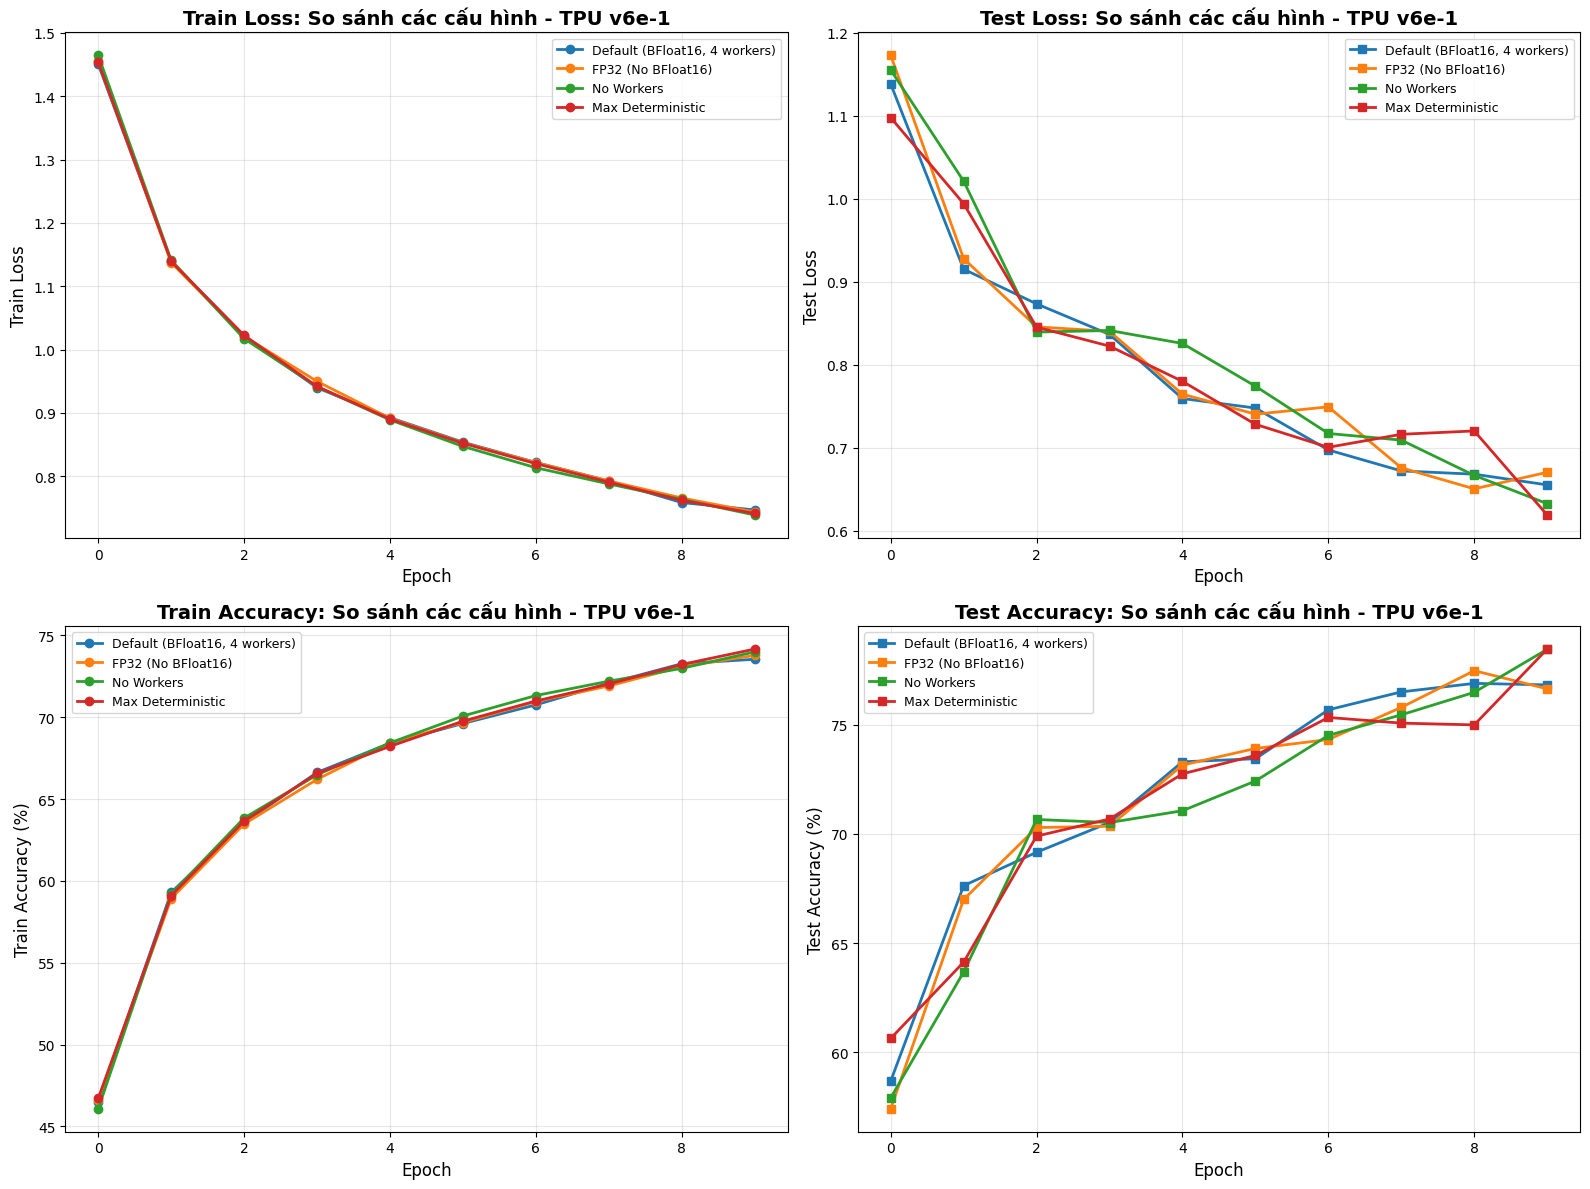


BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - TPU v6e-1
Cấu hình                                           Train Loss   Test Loss    Test Acc    
----------------------------------------------------------------------------------------------------
Default (BFloat16, 4 workers)                      0.7469       0.6555       76.82       %
FP32 (No BFloat16)                                 0.7436       0.6707       76.64       %
No Workers                                         0.7389       0.6329       78.45       %
Max Deterministic                                  0.7413       0.6193       78.46       %

PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)
Cấu hình                                           Test Acc     Độ lệch     
----------------------------------------------------------------------------------------------------
Default (BFloat16, 4 workers)                      76.82       % -1.64%
FP32 (No BFloat16)                                 76.64       % -1.82%
No Workers             

In [8]:
def compare_all_configs(histories, labels):
    """So sánh tất cả các cấu hình"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Loss', fontsize=12)
    ax.set_title('Train Loss: So sánh các cấu hình - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Loss', fontsize=12)
    ax.set_title('Test Loss: So sánh các cấu hình - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Accuracy (%)', fontsize=12)
    ax.set_title('Train Accuracy: So sánh các cấu hình - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Test Accuracy: So sánh các cấu hình - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/deterministic_configs_comparison_TPU_v6e1.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*100)
    print("BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - TPU v6e-1")
    print("="*100)
    print(f"{'Cấu hình':<50} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*100)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<50} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*100)

    # Phân tích độ lệch
    print("\n" + "="*100)
    print("PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)")
    print("="*100)
    if len(histories) > 0:
        baseline = histories[-1]  # Max deterministic
        baseline_test_acc = baseline['test_acc'][-1]

        print(f"{'Cấu hình':<50} {'Test Acc':<12} {'Độ lệch':<12}")
        print("-"*100)
        for hist, label in zip(histories, labels):
            test_acc = hist['test_acc'][-1]
            diff = test_acc - baseline_test_acc
            print(f"{label:<50} {test_acc:<12.2f}% {diff:+.2f}%")
    print("="*100)

# So sánh
if 'history_default' in globals() and 'history_fp32' in globals() and 'history_no_workers' in globals() and 'history_max_deterministic' in globals():
    if history_default is not None and history_fp32 is not None and history_no_workers is not None and history_max_deterministic is not None:
        all_histories = [
            history_default,
            history_fp32,
            history_no_workers,
            history_max_deterministic
        ]

        all_labels = [
            "Default (BFloat16, 4 workers)",
            "FP32 (No BFloat16)",
            "No Workers",
            "Max Deterministic"
        ]

        compare_all_configs(all_histories, all_labels)


## 6. Kết luận cho TPU v6e-1

**Đặc điểm TPU v6e-1**:
- Architecture: v6e (Edge TPU)
- ❌ Không hỗ trợ TF32 (đây là tính năng NVIDIA GPU)
- ❌ Không có cuDNN benchmark (đây là tính năng NVIDIA GPU)
- ✅ Hỗ trợ BFloat16 (mặc định cho hiệu suất tốt hơn)
- ✅ Hỗ trợ FP32

**Quan sát từ các test trên TPU v6e-1**:

1. **TF32**: TPU không hỗ trợ TF32, nên không có test này
2. **BFloat16 vs FP32**: Sử dụng FP32 có thể giúp reproducibility tốt hơn nhưng chậm hơn
3. **num_workers**: Đặt = 0 loại bỏ non-determinism từ DataLoader
4. **Deterministic Algorithms**: Giúp reproducibility tốt nhất nhưng có thể chậm và không hỗ trợ tất cả operations
5. **XLA Compilation**: TPU sử dụng XLA compiler, có thể tạo ra các kernel khác nhau giữa các lần chạy, ảnh hưởng đến reproducibility

**Khuyến nghị cho TPU v6e-1**:
- Để reproducibility tốt nhất: Tắt BFloat16 (dùng FP32), num_workers=0, bật deterministic algorithms
- Để performance tốt nhất: Bật BFloat16, nhiều workers
- Cân bằng: Tắt BFloat16, num_workers=0 (chấp nhận chậm hơn một chút)

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/` với tên TPU v6e-1
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060, H100)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh giữa TPU và GPU
